# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
from scipy.stats import expon

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [2]:
from scipy.stats import uniform
uniform.rvs(2, 8, size=10)

array([8.49833663, 9.00445231, 2.46319337, 4.89200821, 3.51871986,
       3.92253344, 8.90482636, 2.29289406, 7.7767075 , 5.23019369])

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

2. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

3. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

python
from scipy.stats import uniform

uniform.rvs(2, 8, size=10)


In [3]:
def dist_uniform(bottom, ceiling, count):
    width = ceiling - bottom
    return uniform.rvs(loc=bottom, scale=width, size=count)

In [4]:
set_1 = dist_uniform(10, 15, 100)
set_2 = dist_uniform(10, 60, 1000)

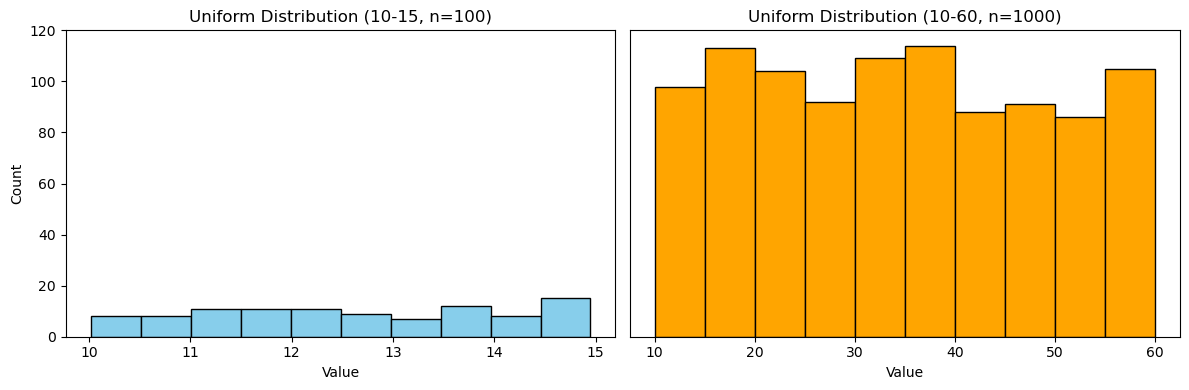

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(set_1, color='skyblue', edgecolor='black')
ax1.set_title('Uniform Distribution (10-15, n=100)')
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')
ax1.set_ylim(0, 120)
ax2.hist(set_2, color='orange', edgecolor='black')
ax2.set_title('Uniform Distribution (10-60, n=1000)')
ax2.set_xlabel('Value')
#ax2.set_ylabel('Count')
ax2.set_ylim(0, 120)
ax2.set_yticks([])
plt.tight_layout()
plt.show()

How are the two distributions different?

The range of first distribution is smaller than the second one, with a small sample, range is 5 and sample 100, while the second one has a range of 50 and sample of 1000. This makes the first distribution more concentrated, while the second one is more spread.

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [6]:
from scipy.stats import norm 

In [7]:
def dist_normal(mean, stddev, count):
    return norm.rvs(loc=mean, scale=stddev, size=count)

In [8]:
set_3 = dist_normal(10, 1, 1000)


In [9]:
set_4 = dist_normal(10, 50, 1000)

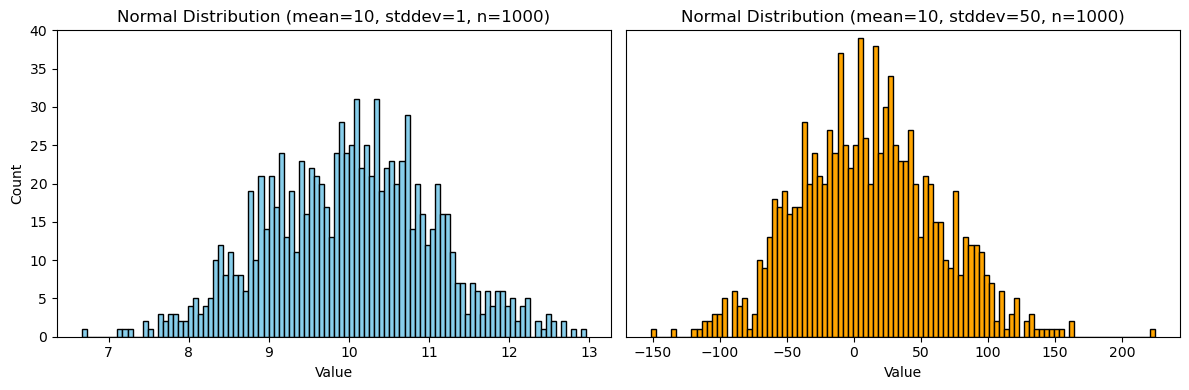

In [10]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
ax3.hist(set_3, bins=100, color='skyblue', edgecolor='black')
ax3.set_title('Normal Distribution (mean=10, stddev=1, n=1000)')
ax3.set_xlabel('Value')
ax3.set_ylabel('Count')
ax3.set_ylim(0, 40)
ax4.hist(set_4, bins=100, color='orange', edgecolor='black')
ax4.set_title('Normal Distribution (mean=10, stddev=50, n=1000)')
ax4.set_xlabel('Value')
#ax4.set_ylabel('Count')
ax4.set_ylim(0, 40)
ax4.set_yticks([])
plt.tight_layout()
plt.show()

How are the two distributions different?

Both distributions share the same mean, but their spread is different:
The first distribution is highly concentrated around the mean, with almost all values falling between 7 and 13 while the second one is much more spread out, with values ranging proximitly from -150 to 150.
This demonstrates that as the standard deviation increases, the variability grows, making the data points much more dispersed even if the center remains the same.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [11]:
df = pd.read_csv('vehicles.csv')

First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

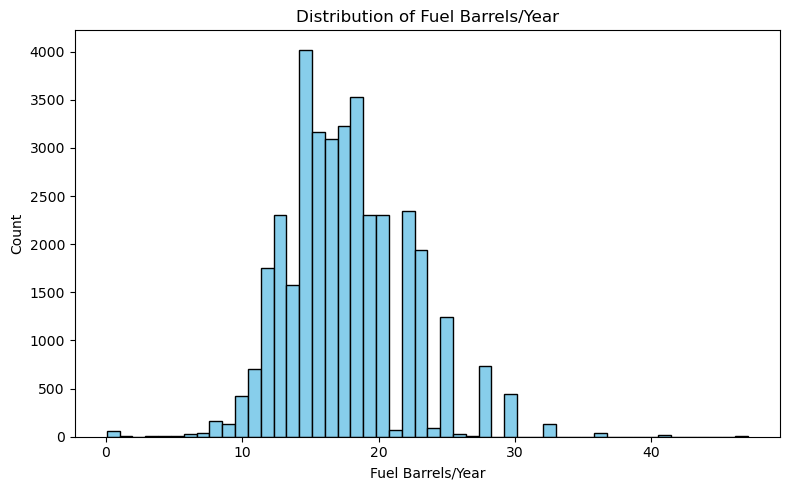

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df['Fuel Barrels/Year'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Fuel Barrels/Year')
plt.xlabel('Fuel Barrels/Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

2. CO2 Emission Grams/Mile 

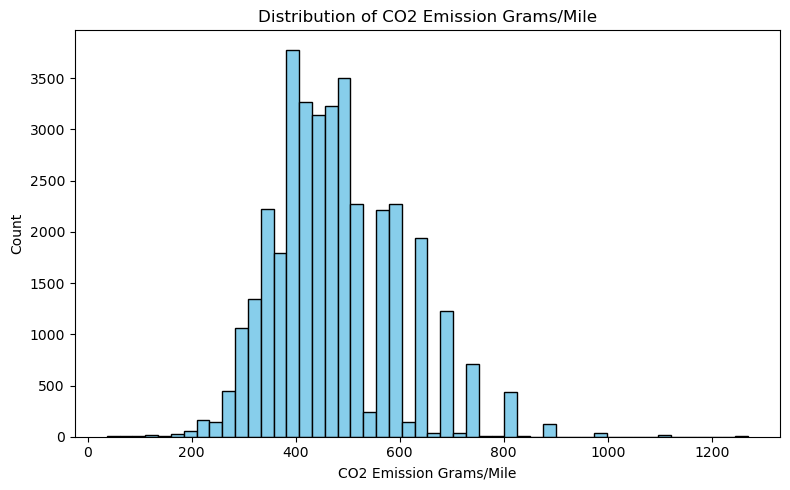

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df['CO2 Emission Grams/Mile'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of CO2 Emission Grams/Mile')
plt.xlabel('CO2 Emission Grams/Mile')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

3. Combined MPG

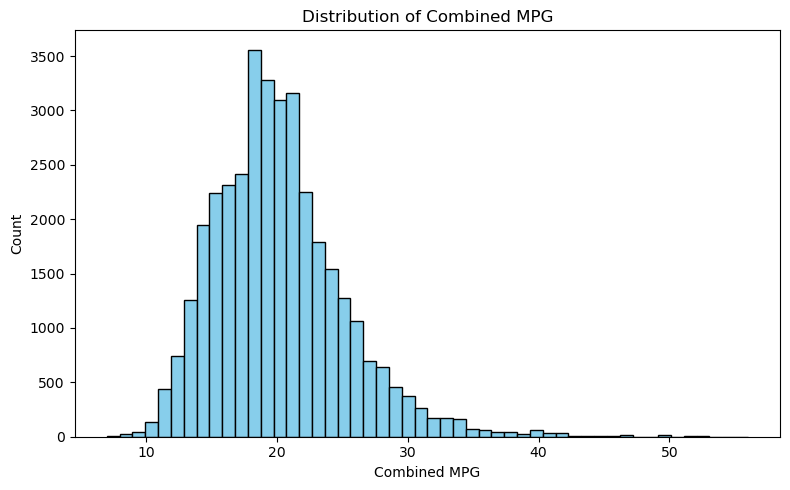

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['Combined MPG'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Combined MPG')
plt.xlabel('Combined MPG')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Which one(s) of the variables are nearly normally distributed? How do you know?

Combined MPG might appear to be the closest to a normal distribution due to its symmetry and data concentration. However, a very significant and well-defined long right tail can be observed, indicating that the apparent symmetry of its peak is not enough to categorize the distribution as normal.
The other two variables present a more symmetric shape, similar to the bell shape of a normal distribution; despite the gaps in the descent from their peaks and some spikes at specific values, they are closer to the center, forming a curve that is nearer to a normal distribution with slightly more symmetric tails. Nevertheless, Fuel Barrels/Year shows greater proximity to the center and better symmetry in its descents and slight tails, making it the closest to the bell shape of a normal distribution.

**Despite this, none of the variables can be categorized as normally distributed.**

To confirm these observations, let's analyze the mean, median, mode, skewness, and kurtosis values for each variable:

In [15]:
cols = ['Fuel Barrels/Year', 'CO2 Emission Grams/Mile', 'Combined MPG']

for col in cols:
    print(f"--- {col} ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Mode: {df[col].mode()[0]:.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurtosis():.2f}\n")

--- Fuel Barrels/Year ---
Mean: 17.61
Median: 17.35
Mode: 18.31
Skewness: 0.64
Kurtosis: 1.47

--- CO2 Emission Grams/Mile ---
Mean: 475.32
Median: 467.74
Mode: 493.72
Skewness: 0.74
Kurtosis: 1.26

--- Combined MPG ---
Mean: 19.93
Median: 19.00
Mode: 18.00
Skewness: 1.07
Kurtosis: 2.72



As observed in the statistical data, the mean, median, and mode of Fuel Barrels/Year maintain the closest proximity to each other, closely resembling a perfect normal distribution where these values would be identical. Furthermore, this variable presents the lowest Skewness, indicating greater symmetry around the central peak. Although it shows a positive Kurtosis, indicating a more leptokurtic shape than a theoretical normal distribution, its overall values deviate the least from normality parameters when compared to the other variables, but none of them can be classified as normally distributed, since the observed values deviate significantly from those expected in a normal distribution.

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

In [16]:
def dist_exp(n=1000):
    return np.random.exponential(scale=10, size=n)


In [17]:
set_5 = dist_exp(10)
set_6 = dist_exp(100)

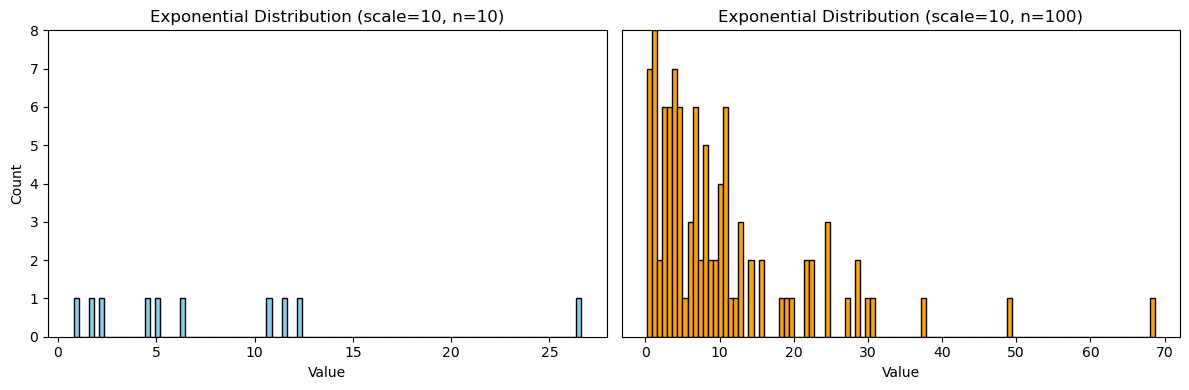

In [18]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))
ax5.hist(set_5, bins=100, color='skyblue', edgecolor='black')
ax5.set_title('Exponential Distribution (scale=10, n=10)')
ax5.set_xlabel('Value')
ax5.set_ylabel('Count')
ax5.set_ylim(0, 8)
ax6.hist(set_6, bins=100, color='orange', edgecolor='black')
ax6.set_title('Exponential Distribution (scale=10, n=100)')
ax6.set_xlabel('Value')
ax6.set_ylim(0, 8)
ax6.set_yticks([])
plt.tight_layout()
plt.show()

How are the two distributions different?

As the use of 100 bins was requested for the histograms, the sample sizes limited to 10 and 100 result in a data visualization that is more dispersed than expected. Since an exponential distribution typically shows a peak concentrated on the left with a long tail extending to the right, the sparse data points in this case lead to a less pronounced peak and a less defined tail.

In the left chart, the peak is almost non-existent, creating the distinct impression of a uniform distribution; it is worth noting that the small sample size significantly contributes to this effect. As for the right chart 100, despite the high number of bins, one can still observe the peak on the left and the long right tail characteristic of the exponential distribution.

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [19]:
mean_time = 10
target = 15

# Na scipy.stats.expon, o parâmetro 'scale' é a média (1/lambda)
prob_less_15 = expon.cdf(x=target, scale=mean_time)

print(f"The probability that a customer will spend less than 15 minutes is: {prob_less_15:.4f} or {prob_less_15*100:.2f}%")

The probability that a customer will spend less than 15 minutes is: 0.7769 or 77.69%


What is the probability that the customer will spend more than 15 minutes

In [20]:
prob_more_than_15 = 1 - expon.cdf(x=15, scale=10)
print(f"The probability that a customer will spend more than 15 minutes is: {prob_more_than_15:.4f} or {prob_more_than_15*100:.2f}%")

The probability that a customer will spend more than 15 minutes is: 0.2231 or 22.31%


In [21]:
prob_more_than_15 = expon.sf(x=15, scale=10)
print(f"The probability that a customer will spend more than 15 minutes is: {prob_more_than_15:.4f} or {prob_more_than_15*100:.2f}%")

The probability that a customer will spend more than 15 minutes is: 0.2231 or 22.31%
